### Importing Libraries

In [36]:
import sys
!"{sys.executable}" -m pip install scikit-learn xgboost

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor

### Creating a Model Dataset

In [38]:
model_df = pd.read_csv("final_delivery_data.csv")

model_df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor',
       'hour_of_day', 'day_of_week', 'is_night', 'hour', 'is_outlier',
       'factor_capped', 'segment_factor_capped', 'time_gap',
       'distance_efficiency', 'is_delayed', 'trip_duration', 'corridor'],
      dtype='object')

In [39]:
model_df = model_df[
    ['segment_actual_time',
        'segment_osrm_time',
        'segment_osrm_distance',
        'route_type',
        'hour_of_day',
        'day_of_week',
        'source_center',
        'destination_center']].dropna()

model_df.shape

(103014, 8)

### Categorical Encoding

In [40]:
cat_cols = ['route_type', 'source_center', 'destination_center']

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    model_df[col] = le.fit_transform(model_df[col].astype(str))

    encoders[col] = le

encoders

{'route_type': LabelEncoder(),
 'source_center': LabelEncoder(),
 'destination_center': LabelEncoder()}

## Baseline Model: XGBoost

### Baseline Features

Target variable: segment_actual_time

In [41]:
baseline_features = [
    'segment_osrm_time',
    'segment_osrm_distance',
    'route_type',
    'hour_of_day',
    'day_of_week',
    'source_center',
    'destination_center']

X = model_df[baseline_features]

y = model_df['segment_actual_time']

### Train-test-split

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Training the Baseline Model

In [43]:
baseline_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)

baseline_model.fit(X,y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluating Baseline Model

In [44]:
# Model score
baseline_model.score(X_test, y_test)

0.6378811111448313

In [45]:
# Model predictions
baseline_pred = baseline_model.predict(X_test)
print(baseline_pred)

[26.029774 36.156246 35.54905  ... 14.973908 32.757168 19.551645]


In [46]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mae

13.131918565663286

In [47]:
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_rmse

np.float64(28.70071086819694)

In [48]:
baseline_within15 = (np.abs(baseline_pred - y_test) / y_test <= 0.15).mean()
baseline_within15

np.float64(0.24933262146289376)

In [49]:
print("BASELINE")
print("MAE :", round(baseline_mae,2))
print("RMSE:", round(baseline_rmse,2))
print("Within 15%:", round(baseline_within15*100, 2), "%")

BASELINE
MAE : 13.13
RMSE: 28.7
Within 15%: 24.93 %


## Graph-Enhanced Model

### GraphSAGE

We cannot use `node2vec` (unsupported), so we hand-roll two complementary embedding strategies:

1. **Structural embeddings** - betweenness centrality, in/out-degree, volume, neighbour delay statistics.  
2. **Mean-aggregated neighbour embeddings (GraphSAGE-style)** - one hop of mean-pooling over neighbours' delay vectors, mimicking a single GraphSAGE layer without a neural network backend.

In [50]:
import pickle
import networkx as nx

with open("G_all.pkl", "rb") as f:
    G_all = pickle.load(f)

print(f"G_all: {G_all.number_of_nodes()} nodes | {G_all.number_of_edges()} edges")

G_all: 1590 nodes | 2508 edges


In [51]:
# ── Per-node structural features ──
# These capture each facility's position and role in the delivery network.
# betweenness  → how often this node lies on shortest paths (chokepoint signal)
# pagerank     → flow authority (high = many trips converge here)
# in/out degree → connectivity richness
# avg_out/in_weight → mean corridor delay multiplier leaving / arriving
# avg_out/in_delay  → mean % delayed trips leaving / arriving

print("Computing betweenness centrality (may take ~30s)...")
betweenness = nx.betweenness_centrality(G_all, weight="weight")

print("Computing PageRank...")
pagerank = nx.pagerank(G_all, weight="weight")

in_degree  = dict(G_all.in_degree())
out_degree = dict(G_all.out_degree())

structural_emb = {}
for node in G_all.nodes():
    out_e = list(G_all.out_edges(node, data=True))
    in_e  = list(G_all.in_edges(node, data=True))

    structural_emb[node] = {
        "emb_betweenness"   : betweenness.get(node, 0),
        "emb_pagerank"      : pagerank.get(node, 0),
        "emb_in_degree"     : in_degree.get(node, 0),
        "emb_out_degree"    : out_degree.get(node, 0),
        "emb_avg_out_weight": np.mean([d["weight"] for _,_,d in out_e]) if out_e else 1.0,
        "emb_avg_in_weight" : np.mean([d["weight"] for _,_,d in in_e])  if in_e  else 1.0,
        "emb_avg_out_delay" : np.mean([d["pct_delayed"] for _,_,d in out_e]) if out_e else 0.0,
        "emb_avg_in_delay"  : np.mean([d["pct_delayed"] for _,_,d in in_e])  if in_e  else 0.0,
    }

struct_df = pd.DataFrame(structural_emb).T
struct_df.index.name = "center"

print(f"Structural embedding shape: {struct_df.shape}")
struct_df.head()

Computing betweenness centrality (may take ~30s)...
Computing PageRank...
Structural embedding shape: (1590, 8)


,emb_betweenness,emb_pagerank,emb_in_degree,emb_out_degree,emb_avg_out_weight,emb_avg_in_weight,emb_avg_out_delay,emb_avg_in_delay
center,,,,,,,,
IND590016AAA,0.000813,0.001194,2.0,1.0,1.596429,1.854921,1.000000,1.000000
IND400072AAJ,0.000410,0.001615,2.0,1.0,9.000000,2.833333,1.000000,0.982456
IND524201AAA,0.000808,0.000748,1.0,1.0,1.266667,0.958871,0.648649,0.083333
IND686540AAA,0.000006,0.000310,2.0,1.0,1.920455,2.014832,1.000000,1.000000
IND757025AAA,0.000000,0.000224,1.0,1.0,2.000000,2.111111,1.000000,1.000000


In [52]:
# ── GraphSAGE: 1-hop mean aggregation ──
# A GraphSAGE layer computes: h_v = CONCAT(h_v_self, MEAN({h_u : u ∈ N(v)}))
# We implement this deterministically — no neural network needed.
# Neighbours are all 1-hop nodes in both directions (predecessors + successors).

feat_cols = list(struct_df.columns)

sage_emb = {}
for node in G_all.nodes():
    self_vec = (struct_df.loc[node, feat_cols].values
                if node in struct_df.index else np.zeros(len(feat_cols)))

    nbr_nodes = list(G_all.predecessors(node)) + list(G_all.successors(node))
    if nbr_nodes:
        nbr_vecs = np.array([
            struct_df.loc[n, feat_cols].values if n in struct_df.index
            else np.zeros(len(feat_cols))
            for n in nbr_nodes
        ])
        nbr_mean = nbr_vecs.mean(axis=0)
    else:
        nbr_mean = np.zeros(len(feat_cols))

    sage_emb[node] = np.concatenate([self_vec, nbr_mean])

self_cols = [f"sage_self_{c}" for c in feat_cols]
nbr_cols  = [f"sage_nbr_{c}"  for c in feat_cols]
sage_all_cols = self_cols + nbr_cols

sage_df = pd.DataFrame(sage_emb, index=sage_all_cols).T
sage_df.index.name = "center"

print(f"GraphSAGE embedding shape: {sage_df.shape}")
sage_df.head()

GraphSAGE embedding shape: (1590, 16)


,sage_self_emb_betweenness,sage_self_emb_pagerank,sage_self_emb_in_degree,sage_self_emb_out_degree,sage_self_emb_avg_out_weight,sage_self_emb_avg_in_weight,sage_self_emb_avg_out_delay,sage_self_emb_avg_in_delay,sage_nbr_emb_betweenness,sage_nbr_emb_pagerank,sage_nbr_emb_in_degree,sage_nbr_emb_out_degree,sage_nbr_emb_avg_out_weight,sage_nbr_emb_avg_in_weight,sage_nbr_emb_avg_out_delay,sage_nbr_emb_avg_in_delay
center,,,,,,,,,,,,,,,,
IND590016AAA,0.000813,0.001194,2.0,1.0,1.596429,1.854921,1.000000,1.000000,0.004699,0.002118,3.333333,3.000000,1.877482,1.919109,0.942647,0.977915
IND400072AAJ,0.000410,0.001615,2.0,1.0,9.000000,2.833333,1.000000,0.982456,0.013329,0.002980,9.666667,9.666667,2.894483,6.671457,0.978137,0.971466
IND524201AAA,0.000808,0.000748,1.0,1.0,1.266667,0.958871,0.648649,0.083333,0.003244,0.001245,2.500000,3.000000,1.356461,2.398909,0.510319,0.847619
IND686540AAA,0.000006,0.000310,2.0,1.0,1.920455,2.014832,1.000000,1.000000,0.000825,0.000593,1.666667,2.000000,3.151141,3.154849,0.961111,0.989418
IND757025AAA,0.000000,0.000224,1.0,1.0,2.000000,2.111111,1.000000,1.000000,0.001823,0.000458,2.500000,2.000000,1.443174,1.867293,0.437500,0.937500


In [53]:
# ── Retrieve original string labels from the encoders ──
# model_df already has source_center / destination_center as encoded integers.
# We need the original strings to join against sage_df's index.

src_labels = encoders["source_center"].inverse_transform(model_df["source_center"])
dst_labels = encoders["destination_center"].inverse_transform(model_df["destination_center"])

graph_df = model_df.copy()
graph_df["_src"] = src_labels
graph_df["_dst"] = dst_labels

# Join source-node embeddings
src_emb = sage_df.add_prefix("src_").reset_index().rename(columns={"center": "_src"})
dst_emb = sage_df.add_prefix("dst_").reset_index().rename(columns={"center": "_dst"})

graph_df = graph_df.merge(src_emb, on="_src", how="left")
graph_df = graph_df.merge(dst_emb, on="_dst", how="left")
graph_df.drop(columns=["_src", "_dst"], inplace=True)

graph_feat_cols = [c for c in graph_df.columns
                   if c.startswith("src_sage") or c.startswith("dst_sage")]

print(f"Graph features added: {len(graph_feat_cols)}")
print(f"Missing values in graph features: {graph_df[graph_feat_cols].isna().sum().sum()}")
print(f"Final dataset shape: {graph_df.shape}")

Graph features added: 32
Missing values in graph features: 0
Final dataset shape: (103014, 40)


### Defining Features and Split

In [54]:
graph_features = [
    "segment_osrm_time",
    "segment_osrm_distance",
    "route_type",
    "hour_of_day",
    "day_of_week",
    "source_center",
    "destination_center",
] + graph_feat_cols

X_graph = graph_df[graph_features]
y_graph = graph_df["segment_actual_time"]

# Same random_state=42 as baseline so train/test splits are comparable
X_graph_train, X_graph_test, y_graph_train, y_graph_test = train_test_split(
    X_graph, y_graph, test_size=0.2, random_state=42
)

print(f"Train: {len(y_graph_train):,}  |  Test: {len(y_graph_test):,}")

Train: 82,411  |  Test: 20,603


### Training the Graph-Enhanced Model

In [55]:
graph_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

graph_model.fit(X_graph_train, y_graph_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluate

In [56]:
graph_pred = graph_model.predict(X_graph_test)

graph_mae  = mean_absolute_error(y_graph_test, graph_pred)
graph_rmse = np.sqrt(mean_squared_error(y_graph_test, graph_pred))
graph_within15 = (
    np.abs(graph_pred - y_graph_test) / y_graph_test.clip(lower=1e-9) <= 0.15
).mean()

print("GRAPH-ENHANCED (GraphSAGE)")
print("MAE        :", round(graph_mae, 2))
print("RMSE       :", round(graph_rmse, 2))
print("Within 15% :", round(graph_within15 * 100, 2), "%")

GRAPH-ENHANCED (GraphSAGE)
MAE        : 12.66
RMSE       : 27.12
Within 15% : 27.3 %


### Head-to-Head Comparison and Graph Advantage

In [57]:
comparison = pd.DataFrame([
    {
        "Model"         : "Baseline XGBoost",
        "MAE (min)"     : round(baseline_mae, 2),
        "RMSE (min)"    : round(baseline_rmse, 2),
        "Within 15% (%)": round(baseline_within15 * 100, 2),
    },
    {
        "Model"         : "Graph-Enhanced XGBoost (GraphSAGE)",
        "MAE (min)"     : round(graph_mae, 2),
        "RMSE (min)"    : round(graph_rmse, 2),
        "Within 15% (%)": round(graph_within15 * 100, 2),
    },
])

print(comparison.to_string(index=False))
print()

mae_delta    = baseline_mae    - graph_mae
rmse_delta   = baseline_rmse   - graph_rmse
within15_delta = (graph_within15 - baseline_within15) * 100

print("=" * 50)
print("GRAPH ADVANTAGE (measured)")
print("=" * 50)
print(f"  MAE reduction     : {mae_delta:+.2f} min  ({mae_delta / baseline_mae * 100:.1f}%)")
print(f"  RMSE reduction    : {rmse_delta:+.2f} min")
print(f"  Within-15% gain   : {within15_delta:+.2f} pp")
print("=" * 50)

                             Model  MAE (min)  RMSE (min)  Within 15% (%)
                  Baseline XGBoost      13.13       28.70           24.93
Graph-Enhanced XGBoost (GraphSAGE)      12.66       27.12           27.30

GRAPH ADVANTAGE (measured)
  MAE reduction     : +0.47 min  (3.6%)
  RMSE reduction    : +1.58 min
  Within-15% gain   : +2.36 pp


### Visualisation

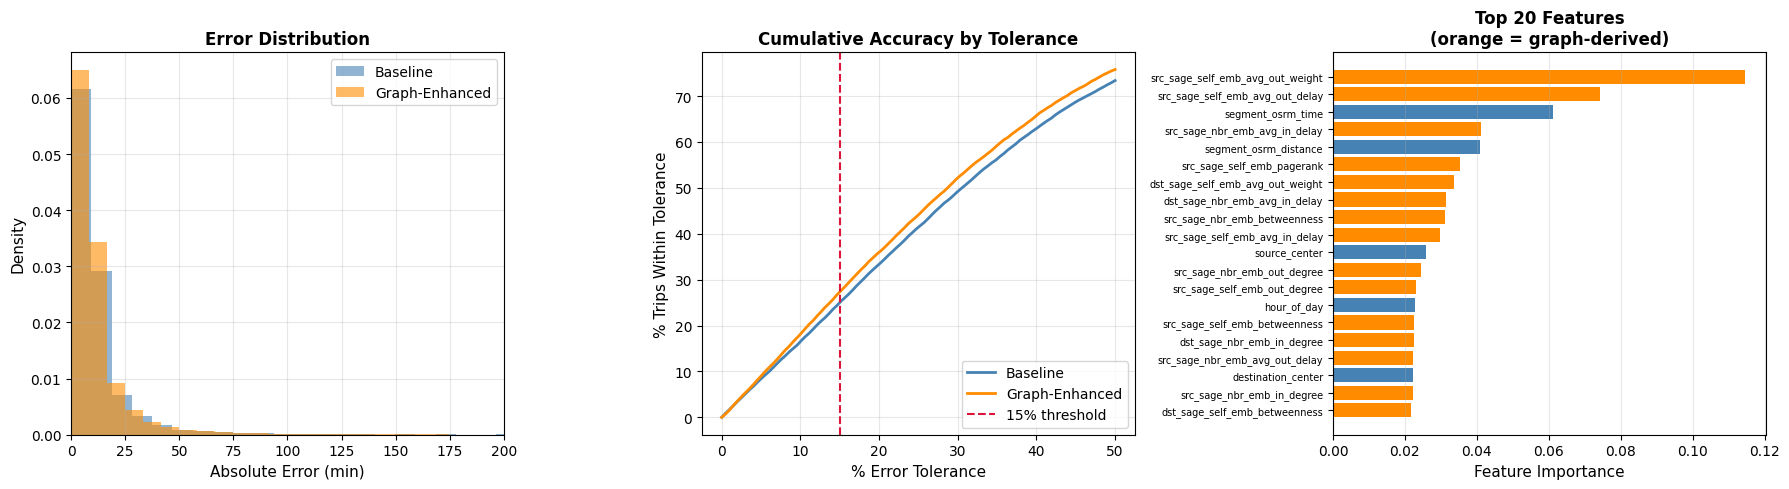

Saved: graph_model_comparison.png


In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: absolute error distributions ──
ax = axes[0]
base_err  = np.abs(baseline_pred - y_test.values)
graph_err = np.abs(graph_pred    - y_graph_test.values)

ax.hist(base_err,  bins=80, alpha=0.6, density=True,
        color="steelblue",  label="Baseline")
ax.hist(graph_err, bins=80, alpha=0.6, density=True,
        color="darkorange", label="Graph-Enhanced")
ax.set_xlabel("Absolute Error (min)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Error Distribution", fontsize=12, fontweight="bold")
ax.set_xlim(0, 200)
ax.legend(); ax.grid(alpha=0.3)

# ── Middle: cumulative % within N% tolerance ──
ax = axes[1]
thresholds = np.linspace(0, 0.5, 100)
y_arr = y_graph_test.values

base_cdf  = [(np.abs(baseline_pred - y_arr) / np.maximum(y_arr, 1) <= t).mean()
             for t in thresholds]
graph_cdf = [(np.abs(graph_pred    - y_arr) / np.maximum(y_arr, 1) <= t).mean()
             for t in thresholds]

ax.plot(thresholds * 100, [v * 100 for v in base_cdf],
        color="steelblue",  lw=2, label="Baseline")
ax.plot(thresholds * 100, [v * 100 for v in graph_cdf],
        color="darkorange", lw=2, label="Graph-Enhanced")
ax.axvline(15, color="crimson", ls="--", lw=1.5, label="15% threshold")
ax.set_xlabel("% Error Tolerance", fontsize=11)
ax.set_ylabel("% Trips Within Tolerance", fontsize=11)
ax.set_title("Cumulative Accuracy by Tolerance", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# ── Right: top 20 feature importances (graph features highlighted) ────────────
ax = axes[2]
fi = (pd.Series(graph_model.feature_importances_, index=graph_features)
        .sort_values(ascending=False)
        .head(20))
colors = ["darkorange" if "sage" in c else "steelblue" for c in fi.index]
ax.barh(range(len(fi)), fi.values, color=colors)
ax.set_yticks(range(len(fi)))
ax.set_yticklabels(fi.index, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_title("Top 20 Features\n(orange = graph-derived)", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("graph_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_model_comparison.png")